# Fine-tuning YOLOv10 on the Urban Issues Dataset

This notebook walks you through **fine-tuning a YOLOv10n (nano) model** to detect urban issues — such as potholes, graffiti, broken infrastructure, etc. — from images, using bounding box predictions.

## What we'll do, step by step:

1. **Set up the environment** — Install dependencies, check GPU
2. **Download the dataset** — Via `kagglehub`
3. **Explore the dataset** — Understand its structure and classes
4. **Prepare the data** — Convert to YOLO format if needed, create a `data.yaml` config
5. **Load the pretrained YOLOv10n model** — Transfer learning from COCO weights
6. **Fine-tune the model** — Train on our custom dataset
7. **Evaluate performance** — mAP, precision, recall, confusion matrix
8. **Run inference** — Visualize predictions on new images
9. **Export the model** — Save for deployment

---

### Key concepts

- **YOLOv10**: The latest generation of the YOLO (You Only Look Once) family. It's a single-stage object detector, meaning it predicts bounding boxes and class labels in one forward pass — making it very fast.
- **Fine-tuning**: Instead of training from scratch (which needs huge datasets and compute), we start from a model pre-trained on COCO (80 common object classes) and *adapt* it to our specific classes. This is called **transfer learning**.
- **Bounding Box**: A rectangle defined by `[x_center, y_center, width, height]` (in YOLO format, normalized 0–1) that localizes an object in an image.

> ⚠️ **Make sure you're using a GPU runtime in Colab**: `Runtime → Change runtime type → T4 GPU`

---
## 1. Environment Setup

We start by installing the required libraries:
- `ultralytics`: the official package that provides YOLOv10 (and v5–v9) — it handles training, evaluation, and inference.
- `kagglehub`: used to download Kaggle datasets programmatically.
- `supervision`: a handy library for visualizing detections.

In [ ]:
# Install required packages
%pip install ultralytics kagglehub supervision --quiet

print("✅ Packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.9/41.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.4/217.4 kB 17.7 MB/s eta 0:00:00
✅ Packages installed successfully!


In [ ]:
import os
import shutil
import random
import json
import yaml
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
import kagglehub
from ultralytics import YOLO

# ── Device check ──────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected. Training will be very slow. Please enable GPU in Colab.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


---
## 2. Download the Dataset

We use `kagglehub` to download the **Urban Issues Dataset** from Kaggle.

> 💡 If you haven't authenticated with Kaggle yet, `kagglehub` will prompt you for your Kaggle username and API key. You can find your API key at https://www.kaggle.com/settings → "API" → "Create New Token".

In [ ]:
# Download the Urban Issues dataset from Kaggle
print("Downloading dataset... (this may take a minute)")
path = kagglehub.dataset_download("akinduhiman/urban-issues-dataset")
print(f"\n✅ Dataset downloaded to: {path}")

100%|██████████| 4.53G/4.53G [00:59<00:00, 81.9MB/s]

Extracting files...



✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19


---
## 3. Explore the Dataset

Before training anything, it's important to **understand what the data looks like**. We'll inspect:
- The folder structure
- The annotation format
- The class distribution (are some classes over/under-represented?)
- A few sample images with their ground-truth boxes

In [ ]:
# Walk through the dataset directory tree
dataset_root = Path(path)

print("📁 Dataset structure (first 3 levels):")
for root, dirs, files in os.walk(dataset_root):
    level = root.replace(str(dataset_root), '').count(os.sep)
    if level > 3:
        continue
    indent = '  ' * level
    print(f"{indent}{Path(root).name}/")
    if level < 2:
        subindent = '  ' * (level + 1)
        # Show first 8 files at each level
        for f in files[:8]:
            print(f"{subindent}{f}")
        if len(files) > 8:
            print(f"{subindent}... and {len(files) - 8} more files")

📁 Dataset structure (first 3 levels):
19/
  config.yaml
  DeadAnimalsPollution/
    DeadAnimalsPollution/
      train/
      valid/
      test/
  Garbage/
    Garbage/
      train/
      valid/
      test/
  FallenTrees/
    FallenTrees/
      train/
      valid/
      test/
  Damaged concrete structures/
    Damaged concrete structures/
      train/
      valid/
      test/
  Potholes and RoadCracks/
    Potholes and RoadCracks/
      train/
      valid/
      test/
  IllegalParking/
    IllegalParking/
      train/
      valid/
      test/
  DamagedRoadSigns/
    DamagedRoadSigns/
      train/
      valid/
      test/
  Graffitti/
    Graffitti/
      train/
      valid/
      test/
  DamagedElectricalPoles/
    DamagedElectricalPoles/
      train/
      valid/
      test/


In [ ]:
# ── Auto-detect dataset format ─────────────────────────────────────────────────
# YOLO datasets can come in different layouts. We'll try to detect:
#   (A) Native YOLO format: images/ + labels/ folders with .txt files
#   (B) COCO JSON format: annotations/*.json
#   (C) A pre-existing data.yaml

all_files = list(dataset_root.rglob('*'))
yaml_files  = [f for f in all_files if f.suffix in ('.yaml', '.yml')]
json_files  = [f for f in all_files if f.suffix == '.json']
txt_files   = [f for f in all_files if ((f.suffix == '.txt') and ("jpg" in f.name))]
image_files = [f for f in all_files if f.suffix.lower() in ('.jpg', '.jpeg', '.png', '.bmp')]

print(f"Found: {len(image_files)} images, {len(txt_files)} .txt files,"
      f" {len(json_files)} .json files, {len(yaml_files)} .yaml files")
print()

if yaml_files:
    print("📄 YAML files found:")
    for y in yaml_files:
        print(f"   {y}")

if json_files:
    print("📄 JSON files found:")
    for j in json_files[:5]:
        print(f"   {j}")

# Show a sample .txt annotation if present
if txt_files:
    sample_txt = txt_files[0]
    print(f"\n📝 Sample annotation ({sample_txt.name}):")
    with open(sample_txt) as f:
        content = f.read()
    print(content[:500])

Found: 47140 images, 37290 .txt files, 0 .json files, 3 .yaml files

📄 YAML files found:
   /root/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/config.yaml
   /root/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/IllegalParking/IllegalParking/data.yaml
   /root/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/DamagedRoadSigns/DamagedRoadSigns/data.yaml

📝 Sample annotation (Dead-Animals-Pollution_original_dead--22--jpg_d10f5a91-8387-4e7b-900a-2001dccde0ff_jpg.rf.0215f1888cd5b839e2529f104aeb8c49.txt):
7 0.49038461538461536 0.4987980769230769 0.9807692307692307 0.9975961538461539



In [ ]:
# ── Try to read an existing data.yaml ─────────────────────────────────────────
# If the dataset ships with a data.yaml, we can read the class names from it.
# Otherwise, we'll collect them from the annotation files.

CLASS_NAMES = None
existing_yaml = None

for y in yaml_files:
    with open(y) as f:
        cfg = yaml.safe_load(f)
    if 'names' in cfg:
        CLASS_NAMES = cfg['names'] if isinstance(cfg['names'], list) else list(cfg['names'].values())
        existing_yaml = y
        print(f"✅ Class names found in {y.name}:")
        for i, n in enumerate(CLASS_NAMES):
            print(f"   [{i}] {n}")
        break

if CLASS_NAMES is None:
    print("No yaml with class names found.")
    print("We will infer class IDs from the .txt label files.")
    # Collect all class IDs used across all label files
    all_class_ids = set()
    for txt_f in txt_files:
        with open(txt_f) as f:
            for line in f:
                line = line.strip()
                if line:
                    cls_id = int(line.split()[0])
                    all_class_ids.add(cls_id)
    num_classes = max(all_class_ids) + 1
    CLASS_NAMES = [f"class_{i}" for i in range(num_classes)]
    print(f"Inferred {num_classes} classes (IDs 0–{num_classes-1}).")
    print("⚠️  Please replace the class names in CLASS_NAMES list below with the actual names.")
    print(f"CLASS_NAMES = {CLASS_NAMES}")

NUM_CLASSES = len(CLASS_NAMES)
print(f"\nTotal classes: {NUM_CLASSES}")

✅ Class names found in config.yaml:
   [0] Damaged Road issues
   [1] Pothole Issues
   [2] Illegal Parking Issues
   [3] Broken Road Sign Issues
   [4] Fallen trees
   [5] Littering/Garbage on Public Places
   [6] Vandalism Issues
   [7] Dead Animal Pollution
   [8] Damaged concrete structures
   [9] Damaged Electric wires and poles

Total classes: 10


In [ ]:
txt_files[:10]

[PosixPath('/root/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/DeadAnimalsPollution/DeadAnimalsPollution/train/labels/Dead-Animals-Pollution_original_dead--22--jpg_d10f5a91-8387-4e7b-900a-2001dccde0ff_jpg.rf.0215f1888cd5b839e2529f104aeb8c49.txt'),
 PosixPath('/root/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/DeadAnimalsPollution/DeadAnimalsPollution/train/labels/Dead-Animals-Pollution_original_dead--1--jpg_35af182d-72b4-478a-9edc-1edac27e90a1_jpg.rf.2e6644ef65d5129f6bb5509fffb7ddfb.txt'),
 PosixPath('/root/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/DeadAnimalsPollution/DeadAnimalsPollution/train/labels/Dead-Animals-Pollution_original_dead--1--jpg_c7f45d4a-af32-4be3-9c26-c1f9c3807656_jpg.rf.2c25de724faefef996319a555434bc20.txt'),
 PosixPath('/root/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19/DeadAnimalsPollution/DeadAnimalsPollution/train/labels/Dead-Animals-Pollution_original_dead

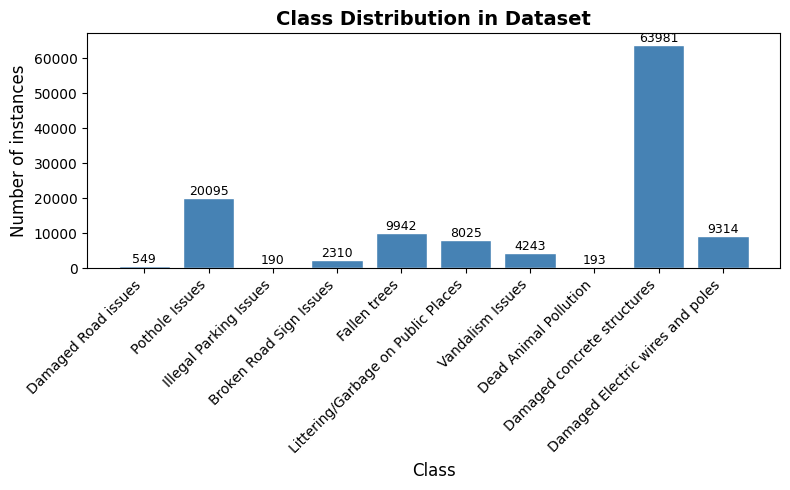


Instance counts per class:
  [0] Damaged Road issues           :   549 instances
  [1] Pothole Issues                : 20095 instances
  [2] Illegal Parking Issues        :   190 instances
  [3] Broken Road Sign Issues       :  2310 instances
  [4] Fallen trees                  :  9942 instances
  [5] Littering/Garbage on Public Places:  8025 instances
  [6] Vandalism Issues              :  4243 instances
  [7] Dead Animal Pollution         :   193 instances
  [8] Damaged concrete structures   : 63981 instances
  [9] Damaged Electric wires and poles:  9314 instances


In [ ]:
# ── Class distribution ─────────────────────────────────────────────────────────
# A healthy dataset should have roughly balanced classes.
# Large imbalances can cause the model to ignore rare classes.

class_counts = Counter()

for txt_f in txt_files:
    with open(txt_f) as f:
        for line in f:
            line = line.strip()
            if line:
                cls_id = int(line.split(" ")[0])
                class_counts[cls_id] += 1

# Plot
ids    = sorted(class_counts.keys())
counts = [class_counts[i] for i in ids]
labels = [CLASS_NAMES[i] if i < len(CLASS_NAMES) else f"id_{i}" for i in ids]

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES * 0.8), 5))
bars = ax.bar(labels, counts, color='steelblue', edgecolor='white')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of instances', fontsize=12)
ax.set_title('Class Distribution in Dataset', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("\nInstance counts per class:")
for i in ids:
    name = CLASS_NAMES[i] if i < len(CLASS_NAMES) else f"id_{i}"
    print(f"  [{i}] {name:30s}: {class_counts[i]:>5d} instances")

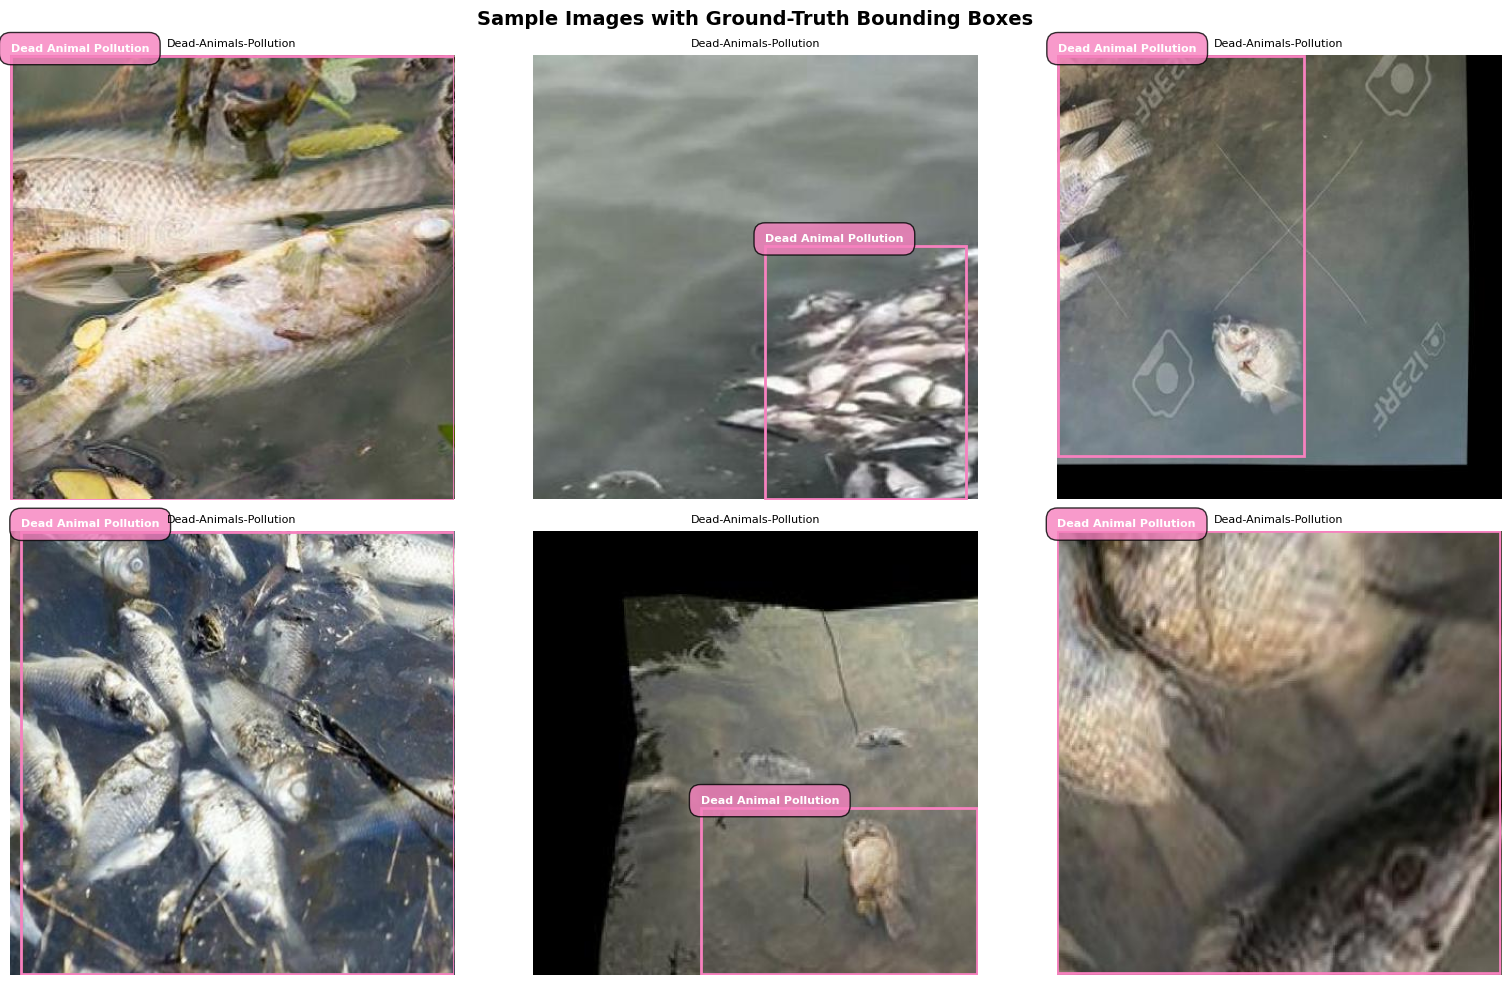

In [ ]:
# ── Visualize sample images with ground-truth bounding boxes ───────────────────
# YOLO .txt label format per line: <class_id> <x_center> <y_center> <width> <height>
# All values are normalized to [0, 1] relative to image dimensions.

def draw_yolo_boxes(image_path, label_path, class_names, ax):
    """Draw YOLO-format bounding boxes on an image."""
    img = Image.open(image_path).convert('RGB')
    w, h = img.size
    ax.imshow(img)

    colors = plt.cm.Set1.colors  # distinct colors for classes

    if label_path.exists():
        with open(label_path) as f:
            lines = f.readlines()
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls_id = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:5])  # normalized
            # Convert to pixel coordinates
            x1 = (xc - bw / 2) * w
            y1 = (yc - bh / 2) * h
            bw_px = bw * w
            bh_px = bh * h
            color = colors[cls_id % len(colors)]
            rect = patches.Rectangle((x1, y1), bw_px, bh_px,
                                      linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            label = class_names[cls_id] if cls_id < len(class_names) else f"id_{cls_id}"
            ax.text(x1, y1 - 4, label,
                    fontsize=8, color='white', fontweight='bold',
                    bbox=dict(facecolor=color, alpha=0.8, pad=1, boxstyle='round'))
    ax.axis('off')


# Find image-label pairs
# Try to find an 'images' folder; otherwise use all images found
img_dirs = [d for d in dataset_root.rglob('images') if d.is_dir()]
if img_dirs:
    all_images = list(img_dirs[0].rglob('*.jpg')) + list(img_dirs[0].rglob('*.png'))
else:
    all_images = image_files

# Sample up to 6 images
sample_imgs = random.sample(all_images, min(6, len(all_images)))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, img_path in zip(axes, sample_imgs):
    # Derive label path: same stem, .txt extension, in 'labels' sibling folder
    lbl_path = Path(str(img_path).replace('images', 'labels')).with_suffix('.txt')
    draw_yolo_boxes(img_path, lbl_path, CLASS_NAMES, ax)
    ax.set_title(img_path.name.split("_")[0], fontsize=8)

for ax in axes[len(sample_imgs):]:
    ax.axis('off')

plt.suptitle('Sample Images with Ground-Truth Bounding Boxes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Prepare Data for Training

YOLOv10 (via Ultralytics) expects the dataset in a specific structure:

```
dataset/
├── images/
│   ├── train/   ← training images
│   └── val/     ← validation images
├── labels/
│   ├── train/   ← .txt annotation files (same name as images)
│   └── val/
└── data.yaml    ← config file (paths + class names)
```

Each `.txt` label file has one line per bounding box:
```
<class_id> <x_center> <y_center> <width> <height>
```
All values except `class_id` are **normalized to [0, 1]**.

The cell below checks whether the dataset is already in this format. If it is (e.g. it already has `train/` and `val/` splits), we skip the reorganization step.

In [ ]:
# ── Check if dataset already has train/val splits ──────────────────────────────
DATASET_DIR = Path('/content/urban_issues_yolo')  # where we'll put the final dataset

has_train_split = any(dataset_root.rglob('train'))
has_val_split   = any(dataset_root.rglob('val'))

print(f"Train split exists: {has_train_split}")
print(f"Val   split exists: {has_val_split}")

if has_train_split and has_val_split:
    print("\n✅ Dataset already has train/val splits. Using existing structure.")
    # Point to the existing structure
    DATASET_DIR = dataset_root
else:
    print("\n⚙️  Creating train/val split (80/20)...")

    # Gather all images (that have a corresponding label file)
    paired = []
    for img_path in image_files:
        lbl_path = Path(str(img_path).replace('images', 'labels')).with_suffix('.txt')
        if not lbl_path.exists():
            # Fallback: look for label next to image
            lbl_path = img_path.with_suffix('.txt')
        if lbl_path.exists():
            paired.append((img_path, lbl_path))

    print(f"Found {len(paired)} image-label pairs.")

    # Shuffle and split 80/20
    random.seed(42)
    random.shuffle(paired)
    split = int(0.8 * len(paired))
    train_pairs = paired[:split]
    val_pairs   = paired[split:]
    print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)}")

    # Create directory structure
    for split_name in ('train', 'val'):
        (DATASET_DIR / 'images' / split_name).mkdir(parents=True, exist_ok=True)
        (DATASET_DIR / 'labels' / split_name).mkdir(parents=True, exist_ok=True)

    # Copy files
    for pairs, split_name in [(train_pairs, 'train'), (val_pairs, 'val')]:
        for img_src, lbl_src in pairs:
            shutil.copy(img_src, DATASET_DIR / 'images' / split_name / img_src.name)
            shutil.copy(lbl_src, DATASET_DIR / 'labels' / split_name / lbl_src.name)

    print(f"\n✅ Dataset organized at: {DATASET_DIR}")

Train split exists: True
Val   split exists: False

⚙️  Creating train/val split (80/20)...
Found 46495 image-label pairs.
Train: 37196 | Val: 9299

✅ Dataset organized at: /content/urban_issues_yolo


In [ ]:
# ── Create data.yaml ───────────────────────────────────────────────────────────
# This YAML file tells Ultralytics where to find the images and what the classes are.
# It is the single config file that controls the entire training pipeline.

YAML_PATH = DATASET_DIR / 'data.yaml'

# If a yaml already exists and has the right structure, use it directly.
if existing_yaml and existing_yaml.parent == DATASET_DIR:
    YAML_PATH = existing_yaml
    print(f"✅ Using existing data.yaml: {YAML_PATH}")
else:
    data_yaml = {
        'path': str(DATASET_DIR),          # absolute root of the dataset
        'train': 'images/train',
        'val':   'images/val',
        'nc':    NUM_CLASSES,               # number of classes
        'names': CLASS_NAMES,               # list of class names
    }

    with open(YAML_PATH, 'w') as f:
        yaml.dump(data_yaml, f, default_flow_style=False, sort_keys=False)

    print(f"✅ Created data.yaml at: {YAML_PATH}")

# Always print the final YAML contents so you can verify it
print("\n📄 data.yaml contents:")
with open(YAML_PATH) as f:
    print(f.read())

✅ Created data.yaml at: /content/urban_issues_yolo/data.yaml

📄 data.yaml contents:
path: /content/urban_issues_yolo
train: images/train
val: images/val
nc: 10
names:
- Damaged Road issues
- Pothole Issues
- Illegal Parking Issues
- Broken Road Sign Issues
- Fallen trees
- Littering/Garbage on Public Places
- Vandalism Issues
- Dead Animal Pollution
- Damaged concrete structures
- Damaged Electric wires and poles



---
## 5. Load the Pretrained YOLOv10n Model

We load **YOLOv10n** (nano) — the smallest and fastest variant in the YOLOv10 family.

| Model      | Params | mAP (COCO) | Latency |
|------------|--------|------------|--------|
| YOLOv10n   | 2.3M   | 38.5%      | fastest |
| YOLOv10s   | 7.2M   | 46.3%      | fast    |
| YOLOv10m   | 15.4M  | 51.1%      | medium  |
| YOLOv10l   | 24.4M  | 53.2%      | slow    |
| YOLOv10x   | 29.5M  | 54.4%      | slowest |

The weights are pre-trained on **COCO** (80 classes). During fine-tuning, the final detection head will be replaced automatically to match our number of classes.

In [ ]:
# Load YOLOv10n with COCO pretrained weights
# 'yolov10n.pt' will be downloaded automatically (~7 MB)
model = YOLO('yolov10n.pt')

print("✅ YOLOv10n model loaded!")
print(f"   Parameters: {sum(p.numel() for p in model.model.parameters()):,}")
print(f"   Pretrained on: COCO (80 classes)")
print(f"   Will be fine-tuned on: {NUM_CLASSES} classes → {CLASS_NAMES}")

✅ YOLOv10n model loaded!
   Parameters: 2,775,520
   Pretrained on: COCO (80 classes)
   Will be fine-tuned on: 10 classes → ['Damaged Road issues', 'Pothole Issues', 'Illegal Parking Issues', 'Broken Road Sign Issues', 'Fallen trees', 'Littering/Garbage on Public Places', 'Vandalism Issues', 'Dead Animal Pollution', 'Damaged concrete structures', 'Damaged Electric wires and poles']


---
## 6. Fine-tune the Model

### Key training hyperparameters explained:

| Parameter | What it does |
|-----------|--------------|
| `epochs` | How many times the model sees the entire dataset. More = better (up to a point). |
| `imgsz` | Images are resized to this size before being fed into the model. 640 is standard. |
| `batch` | Number of images processed together. Larger batch = faster but needs more VRAM. |
| `lr0` | Initial learning rate. Controls how fast weights update. |
| `patience` | Stop training early if validation metric doesn't improve for this many epochs. |
| `optimizer` | Algorithm for updating weights. AdamW is a robust default. |
| `augment` | Whether to apply data augmentation (flips, crops, color jitter) to reduce overfitting. |
| `project` | Folder where training logs and weights are saved. |
| `name` | Sub-folder name for this specific run. |

> 💡 **Tip**: On a Colab T4 GPU, 50 epochs on a small dataset (~500–2000 images) takes roughly 15–30 minutes.

In [ ]:
# ── Fine-tuning configuration ──────────────────────────────────────────────────
# Feel free to adjust these values based on your dataset size and available time.

EPOCHS   = 20      # Increase to 100+ for better results on larger datasets
IMG_SIZE = 640     # Standard YOLO input size (must be multiple of 32)
BATCH    = 16      # Reduce to 8 if you get CUDA out-of-memory errors
LR0      = 1e-3    # Starting learning rate
PATIENCE = 15      # Early stopping patience (epochs without improvement)

# ── Train ──────────────────────────────────────────────────────────────────────
results = model.train(
    data      = str(YAML_PATH),
    epochs    = EPOCHS,
    imgsz     = IMG_SIZE,
    batch     = BATCH,
    lr0       = LR0,
    patience  = PATIENCE,
    optimizer = 'AdamW',
    augment   = True,        # data augmentation to prevent overfitting
    device    = device,
    project   = '/content/yolo_runs',
    name      = 'urban_issues_v10n',
    exist_ok  = True,
    verbose   = True,
)

print("\n✅ Training complete!")

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/urban_issues_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=urban_issues_v10n, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=Tr

---
## 7. Evaluate the Model

After training, we evaluate on the **validation set** using standard object detection metrics:

- **mAP@0.50** (mean Average Precision at IoU=0.50): the primary metric. Higher is better (max = 1.0).
- **mAP@0.50:0.95**: averaged over IoU thresholds from 0.5 to 0.95. Stricter.
- **Precision**: of all the boxes the model predicted, what fraction are correct?
- **Recall**: of all the actual objects, what fraction did the model find?

We also plot the **training curves** to check for overfitting.

In [ ]:
# ── Load the best checkpoint produced by training ──────────────────────────────
best_weights = Path('/content/yolo_runs/urban_issues_v10n/weights/best.pt')
model_best = YOLO(str(best_weights))
print(f"Loaded best weights from: {best_weights}")

# ── Run validation ─────────────────────────────────────────────────────────────
metrics = model_best.val(
    data   = str(YAML_PATH),
    imgsz  = IMG_SIZE,
    device = device,
)

print("\n" + "="*55)
print("VALIDATION RESULTS (best.pt)")
print("="*55)
print(f"  mAP@0.50       : {metrics.box.map50:.4f}")
print(f"  mAP@0.50:0.95  : {metrics.box.map:.4f}")
print(f"  Precision      : {metrics.box.mp:.4f}")
print(f"  Recall         : {metrics.box.mr:.4f}")
print("="*55)

In [ ]:
# ── Plot training curves ───────────────────────────────────────────────────────
# Ultralytics saves a results.csv with per-epoch metrics during training.
# We read and plot it to check:
#   - Are train/val losses decreasing? (good)
#   - Is there a large gap between train and val loss? (overfitting)

import pandas as pd

results_csv = Path('/content/yolo_runs/urban_issues_v10n/results.csv')

if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()  # remove accidental whitespace

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    # Columns to plot — adjust names if your CSV differs
    plot_cols = [
        ('train/box_loss',  'Train Box Loss'),
        ('val/box_loss',    'Val Box Loss'),
        ('train/cls_loss',  'Train Cls Loss'),
        ('val/cls_loss',    'Val Cls Loss'),
        ('metrics/mAP50',   'mAP@0.50'),
        ('metrics/mAP50-95','mAP@0.50:0.95'),
    ]

    for ax, (col, title) in zip(axes, plot_cols):
        if col in df.columns:
            ax.plot(df['epoch'], df[col], linewidth=2)
            ax.set_title(title, fontsize=12, fontweight='bold')
            ax.set_xlabel('Epoch')
            ax.grid(alpha=0.3)
        else:
            ax.set_title(f"{title} (not found)", fontsize=10)
            ax.axis('off')

    plt.suptitle('Training Curves', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("results.csv not found. Training may not have completed.")

In [ ]:
# ── Display Ultralytics-generated evaluation plots ─────────────────────────────
# Ultralytics automatically saves confusion matrix, PR curve, etc.

run_dir = Path('/content/yolo_runs/urban_issues_v10n')
eval_plots = ['confusion_matrix.png', 'PR_curve.png', 'F1_curve.png', 'results.png']

available = [(name, run_dir / name) for name in eval_plots if (run_dir / name).exists()]

if available:
    fig, axes = plt.subplots(1, len(available), figsize=(7 * len(available), 6))
    if len(available) == 1:
        axes = [axes]
    for ax, (name, p) in zip(axes, available):
        img = Image.open(p)
        ax.imshow(img)
        ax.set_title(name.replace('.png', ''), fontsize=12, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No evaluation plots found yet. Run training first.")

---
## 8. Run Inference on New Images

Now let's use the fine-tuned model to **predict bounding boxes on unseen images**.

Key inference parameters:
- `conf`: confidence threshold — only keep predictions above this score (0–1)
- `iou`: IoU threshold for Non-Maximum Suppression (removes duplicate boxes)

We visualize the results with the predicted boxes and class labels.

In [ ]:
# ── Run inference on a sample of validation images ─────────────────────────────

CONF_THRESHOLD = 0.25  # minimum confidence to show a box
IOU_THRESHOLD  = 0.45  # IoU threshold for removing duplicate detections

# Collect a few validation images
val_img_dir = DATASET_DIR / 'images' / 'val'
val_images = list(val_img_dir.glob('*.jpg')) + list(val_img_dir.glob('*.png'))
sample_val = random.sample(val_images, min(6, len(val_images)))

print(f"Running inference on {len(sample_val)} images...")

predictions = model_best.predict(
    source    = sample_val,
    conf      = CONF_THRESHOLD,
    iou       = IOU_THRESHOLD,
    imgsz     = IMG_SIZE,
    device    = device,
    verbose   = False,
)

print(f"✅ Inference done on {len(predictions)} images.")

In [ ]:
# ── Visualize predictions ──────────────────────────────────────────────────────

def visualize_predictions(result, class_names, ax):
    """Plot YOLO prediction result with bounding boxes."""
    # result.plot() returns a BGR numpy array with boxes drawn
    img_bgr = result.plot(conf=True, line_width=2, font_size=10)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(Path(result.path).name, fontsize=8)
    ax.axis('off')

    # Also print detected classes to console
    if result.boxes is not None and len(result.boxes):
        for box in result.boxes:
            cls_id = int(box.cls.item())
            conf   = box.conf.item()
            name   = class_names[cls_id] if cls_id < len(class_names) else f"id_{cls_id}"
            print(f"   → {name} ({conf:.2%})")
    else:
        print("   → (no detections above threshold)")


fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (result, ax) in enumerate(zip(predictions, axes)):
    print(f"\nImage {i+1}: {Path(result.path).name}")
    visualize_predictions(result, CLASS_NAMES, ax)

for ax in axes[len(predictions):]:
    ax.axis('off')

plt.suptitle('YOLOv10n Fine-tuned Predictions on Validation Set',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Inference on a custom image (upload your own) ──────────────────────────────
# To test on your own images, upload them to Colab and set the path below.

# from google.colab import files
# uploaded = files.upload()                          # opens a file picker
# custom_image_path = list(uploaded.keys())[0]

# Or point to any image on disk:
# custom_image_path = '/path/to/your/image.jpg'

# Example: run on first validation image
custom_image_path = str(sample_val[0])

result = model_best.predict(
    source  = custom_image_path,
    conf    = CONF_THRESHOLD,
    iou     = IOU_THRESHOLD,
    imgsz   = IMG_SIZE,
    device  = device,
    verbose = False,
)[0]

img_rgb = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 8))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('YOLOv10n — Custom Image Inference', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDetections:")
if result.boxes is not None and len(result.boxes):
    for box in result.boxes:
        cls_id = int(box.cls.item())
        conf   = box.conf.item()
        xyxy   = box.xyxy[0].tolist()
        name   = CLASS_NAMES[cls_id] if cls_id < len(CLASS_NAMES) else f"id_{cls_id}"
        print(f"  [{name}] conf={conf:.3f}  box=[{xyxy[0]:.0f},{xyxy[1]:.0f},{xyxy[2]:.0f},{xyxy[3]:.0f}]")
else:
    print("  No detections above threshold.")

---
## 9. Export the Model

Once you're happy with the model, you can export it to various formats for deployment:

| Format  | Use case |
|---------|----------|
| `pt`    | PyTorch — default, use for further training |
| `onnx`  | Cross-platform (TensorRT, OpenCV, ONNX Runtime) |
| `tflite`| Mobile / edge devices (Android, Raspberry Pi) |
| `engine`| NVIDIA TensorRT — fastest GPU inference |

We'll export to **ONNX** which is the most portable format.

In [ ]:
# ── Export to ONNX ─────────────────────────────────────────────────────────────
export_path = model_best.export(format='onnx', imgsz=IMG_SIZE)
print(f"\n✅ Model exported to: {export_path}")

# Also copy the best PyTorch weights somewhere easy to find
output_pt = Path('/content/urban_issues_yolov10n_best.pt')
shutil.copy(best_weights, output_pt)
print(f"✅ Best PyTorch weights saved to: {output_pt}")

print("\n📦 To download these files from Colab:")
print("   from google.colab import files")
print(f"   files.download('{output_pt}')")

In [ ]:
# ── (Optional) Download weights from Colab ─────────────────────────────────────
# Uncomment the lines below to download the weights to your local machine.

# from google.colab import files
# files.download(str(output_pt))
# files.download(str(export_path))

---
## Summary

| Step | What we did |
|------|-------------|
| 1    | Installed `ultralytics`, `kagglehub` |
| 2    | Downloaded the Urban Issues dataset via `kagglehub` |
| 3    | Explored the dataset: structure, class distribution, sample images |
| 4    | Organized data into YOLO format and created `data.yaml` |
| 5    | Loaded YOLOv10n with COCO pretrained weights |
| 6    | Fine-tuned for 50 epochs with early stopping |
| 7    | Evaluated: mAP, precision, recall, training curves |
| 8    | Ran inference and visualized predictions |
| 9    | Exported to ONNX + saved `.pt` weights |

### Tips for improving performance

- **More epochs**: Try 100–150 if the mAP is still improving.
- **Larger model**: Switch `yolov10n.pt` → `yolov10s.pt` for better accuracy at slightly more cost.
- **Data augmentation**: Ultralytics supports mosaic, mixup, HSV jitter — all enabled by default.
- **More data**: Collect and annotate more images, especially for under-represented classes.
- **Freeze backbone**: For very small datasets, add `freeze=10` to `model.train()` to freeze the first 10 layers and only train the head — this reduces overfitting.
- **Hyperparameter tuning**: Run `model.tune(data=..., epochs=30, iterations=100)` for automated tuning.